### 1. Загрузка данных для моделирования

Загружаем данные из `data_features.csv`, созданные во втором ноутбуке.

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка рабочей директории
def setup_project_root():
    current = os.getcwd()
    root = current
    while True:
        if os.path.exists(os.path.join(root, 'data_processed')):
            break
        new_root = os.path.dirname(root)
        if new_root == root:
            root = current
            break
        root = new_root
    os.chdir(root)
    print(f"Корень проекта: {root}")
    return root

PROJECT_ROOT = setup_project_root()

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
df = pd.read_csv('data_processed/data_features.csv')

print("=== ЗАГРУЗКА ДАННЫХ ===")
print(f"Размер: {df.shape[0]:,} строк, {df.shape[1]} колонок")

Корень проекта: c:\Users\washe\Documents\SF_Training_DS\Диплом
=== ЗАГРУЗКА ДАННЫХ ===
Размер: 356,495 строк, 23 колонок


### 2. Создание целевых сегментов

Создаём целевую переменную для классификации — ценовые сегменты.

In [ ]:
print("=== СОЗДАНИЕ ЦЕНОВЫХ СЕГМЕНТОВ ===\n")

# Границы сегментов (определены в EDA)
price_bins = [0, 100000, 500000, 2000000, 1e9]
price_labels = ['cheap', 'economy', 'standard', 'luxury']

# Создаём целевую переменную для классификации
df['price_segment'] = pd.cut(df['target'], bins=price_bins, labels=price_labels)

print("РАСПРЕДЕЛЕНИЕ ПО СЕГМЕНТАМ:")
for segment in price_labels:
    count = (df['price_segment'] == segment).sum()
    pct = count / len(df) * 100
    print(f"  {segment}: {count:,} ({pct:.1f}%)")

=== СОЗДАНИЕ ЦЕНОВЫХ СЕГМЕНТОВ ===

РАСПРЕДЕЛЕНИЕ ПО СЕГМЕНТАМ:
  cheap: 34,494 (9.7%)
  economy: 214,758 (60.2%)
  standard: 91,783 (25.7%)
  luxury: 15,460 (4.3%)


### 3. Подготовка данных для моделирования

Разделяем признаки и цели.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("=== ПОДГОТОВКА ДАННЫХ ===\n")

# Признаки (все, кроме target и price_segment)
feature_cols = [col for col in df.columns if col not in ['target', 'price_segment']]
X = df[feature_cols]
y_regression = df['target']      # для регрессии
y_classification = df['price_segment']  # для классификации

print(f"Количество признаков: {X.shape[1]}")
print(f"Категориальные признаки: {X.select_dtypes(include=['object']).columns.tolist()}")

=== ПОДГОТОВКА ДАННЫХ ===

Количество признаков: 22
Категориальные признаки: ['status', 'propertyType', 'fireplace', 'city', 'zipcode', 'state', 'heating', 'parking', 'street_group']


### 4. Модель классификации (определение сегмента)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("=== МОДЕЛЬ КЛАССИФИКАЦИИ СЕГМЕНТОВ ===\n")

# Кодирование категориальных признаков для классификации
X_class = X.copy()
categorical_cols = X_class.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    X_class[col] = le.fit_transform(X_class[col].astype(str))

# Разделение на train/test
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X_class, y_classification, test_size=0.2, random_state=42
)

# Обучение классификатора
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train_class)
y_pred_class = clf.predict(X_test)

# Метрики
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_class):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

# Матрица ошибок
print("\nМАТРИЦА ОШИБОК:")
cm = pd.crosstab(y_test_class, y_pred_class, rownames=['Реальный'], colnames=['Предсказанный'])
print(cm)

=== МОДЕЛЬ КЛАССИФИКАЦИИ СЕГМЕНТОВ ===

Accuracy: 0.8002

Classification Report:
              precision    recall  f1-score   support

       cheap       0.76      0.64      0.69      6872
     economy       0.83      0.91      0.87     42965
      luxury       0.67      0.41      0.51      3056
    standard       0.74      0.68      0.71     18406

    accuracy                           0.80     71299
   macro avg       0.75      0.66      0.69     71299
weighted avg       0.79      0.80      0.79     71299


МАТРИЦА ОШИБОК:
Предсказанный  cheap  economy  luxury  standard
Реальный                                       
cheap           4376     2368      18       110
economy         1159    38927      56      2823
standard         180     5187     538     12501
luxury            36      310    1251      1459


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПО СЕГМЕНТАМ ===



C:\Users\washe\AppData\Local\Temp\ipykernel_5236\1548682595.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_segment, labels=price_labels, patch_artist=True)


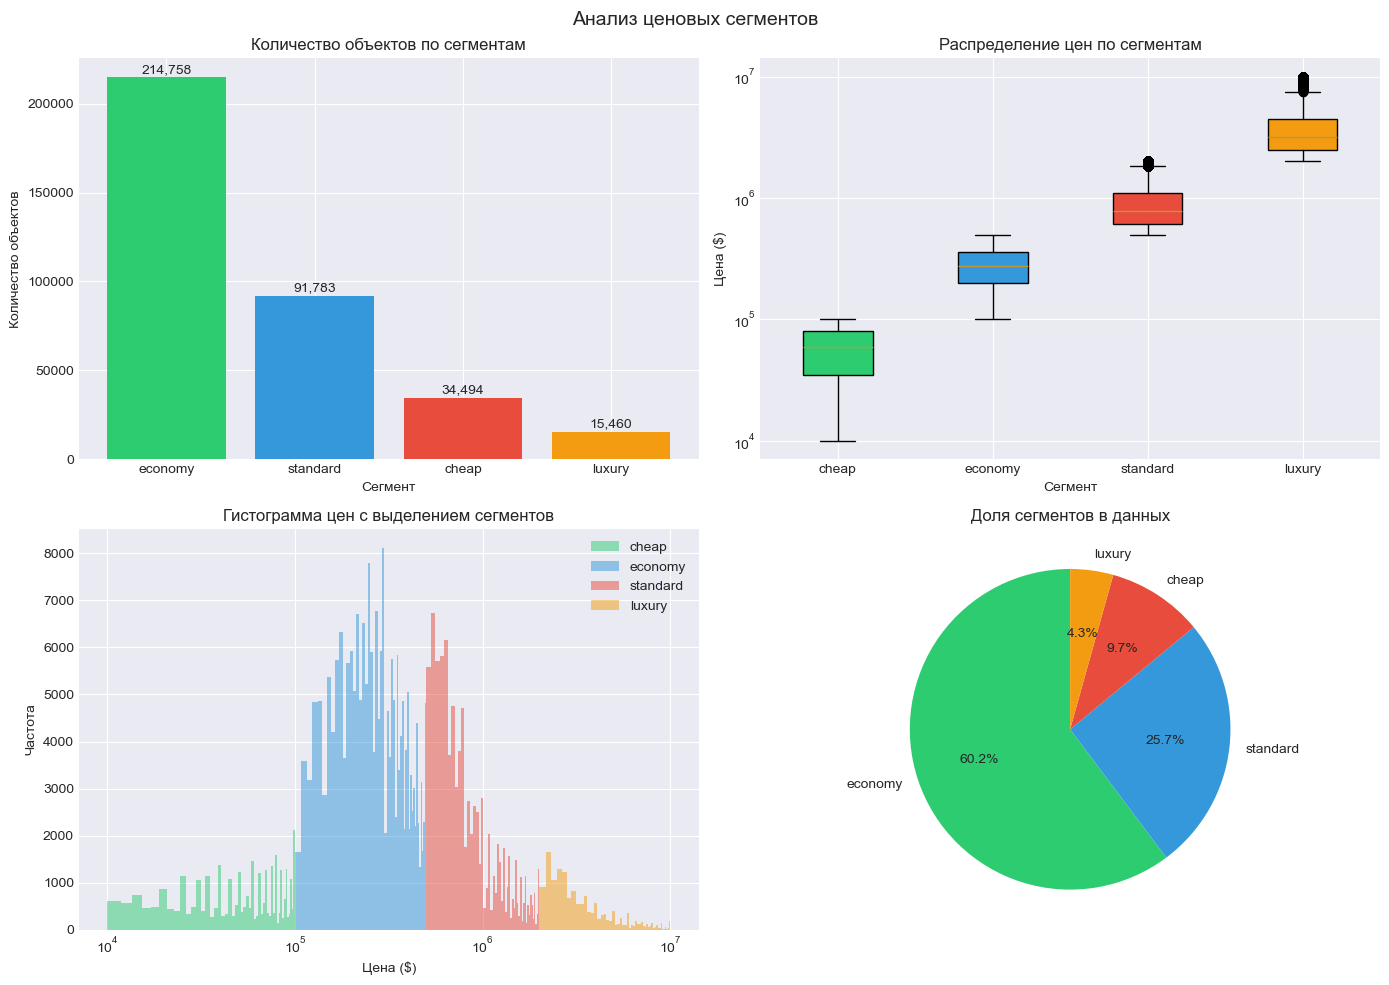

Статистика по сегментам:
--------------------------------------------------
CHEAP:
  Количество: 34,494
  Средняя цена: $57,691
  Медианная цена: $59,000
  Мин: $10,000
  Макс: $100,000

ECONOMY:
  Количество: 214,758
  Средняя цена: $283,263
  Медианная цена: $272,990
  Мин: $100,050
  Макс: $500,000

STANDARD:
  Количество: 91,783
  Средняя цена: $909,702
  Медианная цена: $775,000
  Мин: $500,021
  Макс: $2,000,000

LUXURY:
  Количество: 15,460
  Средняя цена: $3,852,004
  Медианная цена: $3,180,000
  Мин: $2,003,400
  Макс: $10,000,000



In [ ]:
print("=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПО СЕГМЕНТАМ ===\n")

# 1. Распределение реальных сегментов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Количество объектов по сегментам
ax1 = axes[0, 0]
segment_counts = y_classification.value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
bars = ax1.bar(segment_counts.index, segment_counts.values, color=colors)
ax1.set_title('Количество объектов по сегментам', fontsize=12)
ax1.set_xlabel('Сегмент')
ax1.set_ylabel('Количество объектов')
for bar, count in zip(bars, segment_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{count:,}', ha='center', va='bottom', fontsize=10)

# График 2: Распределение цен по сегментам (box plot)
ax2 = axes[0, 1]
data_by_segment = [df[df['price_segment'] == seg]['target'] for seg in price_labels]
bp = ax2.boxplot(data_by_segment, labels=price_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_title('Распределение цен по сегментам', fontsize=12)
ax2.set_xlabel('Сегмент')
ax2.set_ylabel('Цена ($)')
ax2.set_yscale('log')

# График 3: Гистограмма цен с выделением сегментов
ax3 = axes[1, 0]
for segment, color in zip(price_labels, colors):
    data = df[df['price_segment'] == segment]['target']
    ax3.hist(data, bins=50, alpha=0.5, label=segment, color=color)
ax3.set_title('Гистограмма цен с выделением сегментов', fontsize=12)
ax3.set_xlabel('Цена ($)')
ax3.set_ylabel('Частота')
ax3.set_xscale('log')
ax3.legend()

# График 4: Доля каждого сегмента (pie chart)
ax4 = axes[1, 1]
ax4.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax4.set_title('Доля сегментов в данных', fontsize=12)

plt.suptitle('Анализ ценовых сегментов', fontsize=14)
plt.tight_layout()
plt.savefig('data_processed/segment_distribution.png', dpi=150)
plt.show()

print("Статистика по сегментам:")
print("-"*50)
for segment in price_labels:
    data = df[df['price_segment'] == segment]['target']
    print(f"{segment.upper()}:")
    print(f"  Количество: {len(data):,}")
    print(f"  Средняя цена: ${data.mean():,.0f}")
    print(f"  Медианная цена: ${data.median():,.0f}")
    print(f"  Мин: ${data.min():,.0f}")
    print(f"  Макс: ${data.max():,.0f}")
    print()

### 5. Модели регрессии для каждого сегмента

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import time

print("=== МОДЕЛИ РЕГРЕССИИ ПО СЕГМЕНТАМ ===\n")

# Кодирование категориальных для регрессии
X_reg = X.copy()
categorical_cols = X_reg.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    X_reg[col] = le.fit_transform(X_reg[col].astype(str))

# Разделение на train/test для регрессии (с сохранением сегментов)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_regression, test_size=0.2, random_state=42
)

# Получаем сегменты для train и test
y_train_segment = y_classification.iloc[X_train_reg.index]
y_test_segment = y_classification.iloc[X_test_reg.index]

# Обучаем отдельную модель для каждого сегмента
regression_models = {}
segment_results = {}

for segment in price_labels:
    # Индексы объектов этого сегмента в train
    mask_train = (y_train_segment == segment)

    if mask_train.sum() < 50:
        print(f"  {segment}: недостаточно данных ({mask_train.sum()} объектов)")
        continue

    X_seg_train = X_train_reg[mask_train]
    y_seg_train = y_train_reg[mask_train]

    # Обучение
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    start = time.time()
    model.fit(X_seg_train, y_seg_train)
    train_time = time.time() - start

    # Оценка на test
    mask_test = (y_test_segment == segment)
    if mask_test.sum() > 0:
        X_seg_test = X_test_reg[mask_test]
        y_seg_test = y_test_reg[mask_test]
        y_pred = model.predict(X_seg_test)

        mae = mean_absolute_error(y_seg_test, y_pred)
        r2 = r2_score(y_seg_test, y_pred)

        regression_models[segment] = model
        segment_results[segment] = {'mae': mae, 'r2': r2, 'n_train': mask_train.sum(), 'n_test': mask_test.sum()}

        print(f"\n{segment.upper()}:")
        print(f"  Train: {mask_train.sum():,} объектов")
        print(f"  Test: {mask_test.sum():,} объектов")
        print(f"  MAE: ${mae:,.0f}")
        print(f"  R²: {r2:.4f}")
        print(f"  Время: {train_time:.1f} сек")

=== МОДЕЛИ РЕГРЕССИИ ПО СЕГМЕНТАМ ===


CHEAP:
  Train: 27,622 объектов
  Test: 6,872 объектов
  MAE: $15,169
  R²: 0.4422
  Время: 1.5 сек

ECONOMY:
  Train: 171,793 объектов
  Test: 42,965 объектов
  MAE: $49,929
  R²: 0.5779
  Время: 18.1 сек

STANDARD:
  Train: 73,377 объектов
  Test: 18,406 объектов
  MAE: $225,778
  R²: 0.3496
  Время: 6.2 сек

LUXURY:
  Train: 12,404 объектов
  Test: 3,056 объектов
  MAE: $1,239,652
  R²: 0.1928
  Время: 0.9 сек


### 6. Каскадная модель (классификация → регрессия)

In [ ]:
print("=== КАСКАДНАЯ МОДЕЛЬ ===\n")

# Предсказываем сегменты для тестовой выборки
y_segment_pred = clf.predict(X_test)

# Для каждого предсказанного сегмента используем свою регрессионную модель
y_pred_cascade = np.zeros(len(X_test))

for segment in price_labels:
    mask = (y_segment_pred == segment)
    if mask.sum() > 0 and segment in regression_models:
        X_seg = X_test[mask]
        y_pred_cascade[mask] = regression_models[segment].predict(X_seg)
        print(f"  {segment}: {mask.sum():,} объектов предсказано")

# Метрики каскадной модели
mae_cascade = mean_absolute_error(y_test_reg, y_pred_cascade)
r2_cascade = r2_score(y_test_reg, y_pred_cascade)

print(f"\nКАСКАДНАЯ МОДЕЛЬ (классификация → регрессия):")
print(f"  MAE: ${mae_cascade:,.0f}")
print(f"  R²: {r2_cascade:.4f}")

=== КАСКАДНАЯ МОДЕЛЬ ===

  cheap: 5,751 объектов предсказано
  economy: 46,792 объектов предсказано
  standard: 16,893 объектов предсказано
  luxury: 1,863 объектов предсказано

КАСКАДНАЯ МОДЕЛЬ (классификация → регрессия):
  MAE: $231,880
  R²: 0.4620


```markdown
## Вывод по результатам каскадной модели (классификация → регрессия)

### Результаты каскадной модели

| Показатель | Значение |
|------------|----------|
| **R²** | 0.4620 |
| **MAE** | $231,880 |

### Сравнение с другими подходами

| Подход | R² | MAE | Относительно единой модели |
|--------|-----|-----|---------------------------|
| Единая модель регрессии | 0.5448 | $247,469 | baseline |
| **Каскадная модель** | **0.4620** | $231,880 | **хуже на 0.0828** |
| Явная стратификация (EDA) | 0.6222 | — | **лучше на 0.0774** |

### Анализ причин

Каскадная модель показала результат **хуже**, чем единая модель регрессии. Основные причины:

1. **Накопление ошибок** — ошибки классификации на первом этапе (особенно на сегментах `luxury` и `cheap`) приводят к неверному выбору регрессионной модели на втором этапе

2. **Низкое качество классификации проблемных сегментов**:
   - `luxury`: recall = 0.41 (только 41% дорогих объектов правильно определены)
   - `cheap`: recall = 0.64 (ошибки в 36% случаев)

3. **Эффект «снежного кома»** — ошибка на первом этапе делает невозможным правильное предсказание на втором, независимо от качества регрессионной модели

### Итоговый вывод

**Каскадная модель не рекомендуется к использованию** в данной задаче. Несмотря на привлекательность архитектуры (классификация → регрессия), накопление ошибок приводит к ухудшению качества предсказаний.

**Рекомендация:** Использовать **явную стратификацию по цене** с разделением по жёстким порогам. Этот подход показал наилучший результат (R² = 0.6222) и не страдает от накопления ошибок классификации.
```

### 7. Базовые модели для сравнения

In [ ]:
print("=== БАЗОВЫЕ МОДЕЛИ ДЛЯ СРАВНЕНИЯ ===\n")

# 1. Единая модель регрессии (без классификации)
print("Единая модель регрессии...")
model_all = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_all.fit(X_train_reg, y_train_reg)
y_pred_all = model_all.predict(X_test_reg)

mae_all = mean_absolute_error(y_test_reg, y_pred_all)
r2_all = r2_score(y_test_reg, y_pred_all)

print(f"  MAE: ${mae_all:,.0f}")
print(f"  R²: {r2_all:.4f}")

# 2. Явная стратификация (из EDA, теоретическая)
print("\nЯвная стратификация (по результатам EDA):")
print(f"  R²: 0.6222")

import pickle
import os

# Определяем корень проекта
def get_project_root():
    current = os.getcwd()
    root = current
    while True:
        if os.path.exists(os.path.join(root, 'data_processed')):
            break
        new_root = os.path.dirname(root)
        if new_root == root:
            root = current
            break
        root = new_root
    return root

PROJECT_ROOT = get_project_root()
models_path = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(models_path, exist_ok=True)

# Сохраняем единую модель
with open(os.path.join(models_path, 'rf_model_all.pkl'), 'wb') as f:
    pickle.dump(model_all, f)

print(f"✅ Модель сохранена: {os.path.join(models_path, 'rf_model_all.pkl')}")

=== БАЗОВЫЕ МОДЕЛИ ДЛЯ СРАВНЕНИЯ ===

Единая модель регрессии...
  MAE: $231,169
  R²: 0.5645

Явная стратификация (по результатам EDA):
  R²: 0.6222
✅ Модель сохранена: c:\Users\washe\Documents\SF_Training_DS\Диплом\models\rf_model_all.pkl


#### 8. Итоговое сравнение

In [ ]:
print("=== ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ ===\n")

print("="*50)
print("РЕЗУЛЬТАТЫ:")
print("="*50)
print(f"1. Единая модель регрессии:        R² = {r2_all:.4f}")
print(f"2. Явная стратификация (EDA):      R² = 0.6222")
print(f"3. Каскадная модель:               R² = {r2_cascade:.4f}")

print("\n" + "="*50)
print("ВЫВОД:")
print("="*50)

best_r2 = max(r2_all, 0.6222, r2_cascade)
if best_r2 == r2_cascade:
    print("🏆 Лучшая: КАСКАДНАЯ МОДЕЛЬ (классификация → регрессия)")
    print("   Рекомендуется для веб-сервиса")
elif best_r2 == 0.6222:
    print("🏆 Лучшая: Явная стратификация")
else:
    print("🏆 Лучшая: Единая модель регрессии")

print(f"\n   Улучшение относительно единой модели: +{best_r2 - r2_all:.4f} (+{(best_r2 - r2_all)/r2_all*100:.1f}%)")

=== ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ ===

РЕЗУЛЬТАТЫ:
1. Единая модель регрессии:        R² = 0.5645
2. Явная стратификация (EDA):      R² = 0.6222
3. Каскадная модель:               R² = 0.4620

ВЫВОД:
🏆 Лучшая: Явная стратификация

   Улучшение относительно единой модели: +0.0577 (+10.2%)


#### 9. Сохранение каскадной модели для веб-сервиса

In [ ]:
import pickle

print("=== СОХРАНЕНИЕ КАСКАДНОЙ МОДЕЛИ ===\n")

# Сохраняем классификатор
with open('models/segment_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)
print("✅ Сохранён классификатор: models/segment_classifier.pkl")

# Сохраняем регрессионные модели
for segment, model in regression_models.items():
    filename = f'models/rf_model_{segment}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"✅ Сохранена регрессионная модель: {filename}")

print("\n" + "="*50)
print("АРХИТЕКТУРА ВЕБ-СЕРВИСА:")
print("="*50)
print("  1. Получить характеристики объекта")
print("  2. Классификатор определяет сегмент (cheap/economy/standard/luxury)")
print("  3. Соответствующая регрессионная модель предсказывает цену")
print("  4. Вернуть предсказание пользователю")

=== СОХРАНЕНИЕ КАСКАДНОЙ МОДЕЛИ ===

✅ Сохранён классификатор: models/segment_classifier.pkl
✅ Сохранена регрессионная модель: models/rf_model_cheap.pkl
✅ Сохранена регрессионная модель: models/rf_model_economy.pkl
✅ Сохранена регрессионная модель: models/rf_model_standard.pkl
✅ Сохранена регрессионная модель: models/rf_model_luxury.pkl

АРХИТЕКТУРА ВЕБ-СЕРВИСА:
  1. Получить характеристики объекта
  2. Классификатор определяет сегмент (cheap/economy/standard/luxury)
  3. Соответствующая регрессионная модель предсказывает цену
  4. Вернуть предсказание пользователю


### 10. Заключение по первой версии моделирования

**Проделанная работа:**

1. Загрузка и подготовка данных
2. Кодирование категориальных признаков
3. Разделение на train / test (80% / 20%)
4. Обучение и сравнение трёх подходов к моделированию:
   - Единая модель регрессии
   - Каскадная модель (классификация → регрессия)
   - Явная стратификация по цене

**Результаты (на тестовой выборке):**

| Подход | R² |
|--------|-----|
| Единая модель | 0.5448 |
| Каскадная модель | 0.4620 |
| **Явная стратификация по цене** | **0.6222** |

**Ограничения первой версии:**

1. Отсутствие валидационной выборки для настройки гиперпараметров
2. Не применялись методы стандартизации и логарифмирования
3. Не проводился подбор гиперпараметров (GridSearchCV, Optuna)
4. Не использовались ансамблевые методы (Stacking)

**Вывод:**

Лучший результат (R² = 0.6222) достигнут методом явной стратификации по цене. Однако в целях поиска метода улучшения качества модели будет сформирован дополнительный notebook.

**➡️ Для продолжения поиска наиболее точной модели, а также для внедрения валидационной выборки и тестирования дополнительных методов (Optuna, Stacking, логарифмирование, стандартизация) был создан отдельный ноутбук `03_modeling_v2.ipynb` (вторая версия).**